In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

In [3]:
x,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1 ,noise=20,random_state=13)

[28.16404017]
-2.7130725669241036


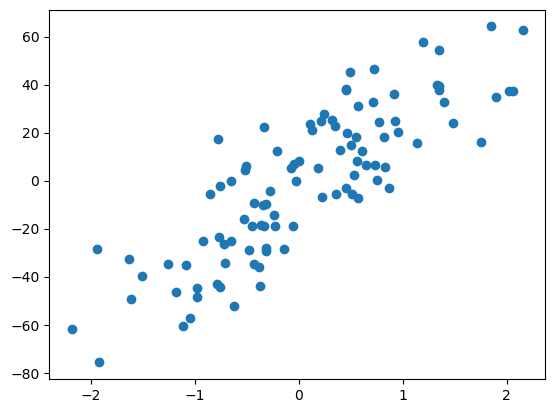

In [4]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
print(lr.coef_)
print(lr.intercept_)
plt.scatter(x,y)


# now impleminting the lasso regression and displaying using plots

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.078e+04, tolerance: 7.701e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

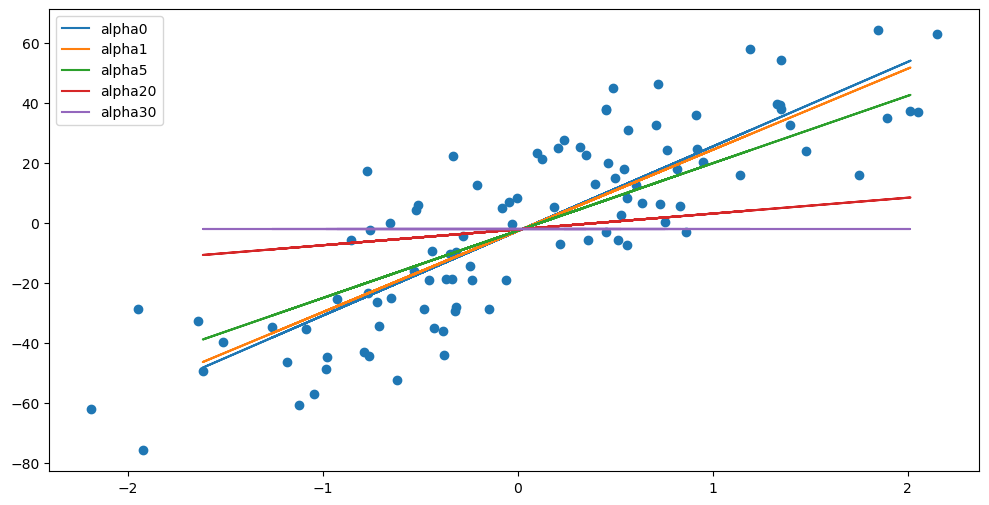

In [5]:
alphas=[0,1,5,20,30]
plt.figure(figsize=(12,6))
plt.scatter(x,y)
for i in alphas:
    lasso=Lasso(alpha=i)
    lasso.fit(x_train,y_train)
    plt.plot(x_test,lasso.predict(x_test),label="alpha{}".format(i))
plt.legend()
plt.show()
    

# now applying on polynomial data


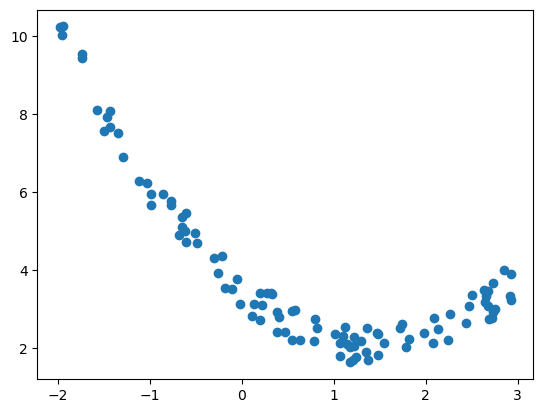

In [6]:
m=100
x1=5*np.random.rand(m,1)-2
x2=0.7*x1**2-2*x1+3+np.random.rand(m,1)

plt.scatter(x1,x2)
plt.show()

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.323e+00, tolerance: 4.463e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

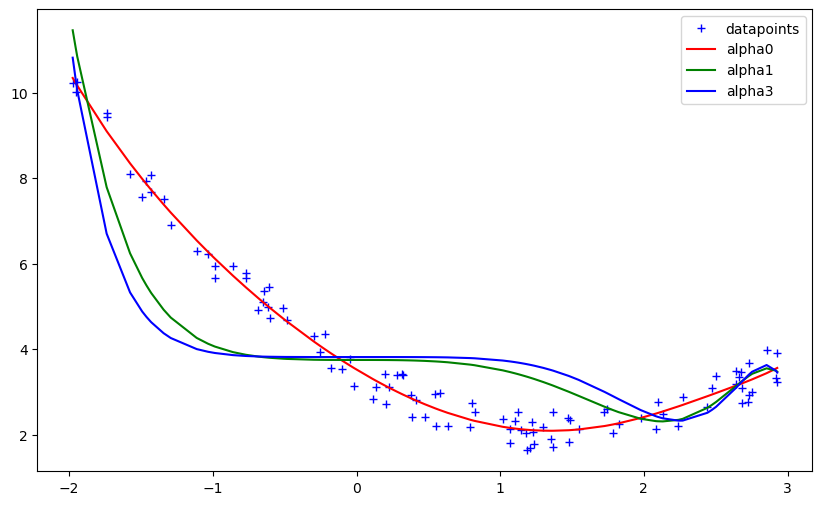

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_lasso(x1,x2,alpha):
    model=Pipeline([
        ("polynomial_features",PolynomialFeatures(degree=16)),
        ("lasso",Lasso(alpha=alpha))
    ])
    model.fit(x1,x2)
    return model.predict(x1)

alphas=[0,1,3,5,10]
cs=['r','g','b']

plt.figure(figsize=(10,6))
plt.plot(x1,x2,'b+',label="datapoints")

for alpha , c in zip(alphas,cs):
    preds=get_preds_lasso(x1,x2,alpha)
    plt.plot(sorted(x1[:,0]),preds[np.argsort(x1[:,0])],c,label="alpha{}".format(alpha))

plt.legend()
plt.show()